In [2]:
import numpy as np
from scipy.linalg import toeplitz

In [4]:
# Signal size
n = 6

# Two filters
h1 = np.array([1, 2, 1]) # Weighted mean filter
h2 = np.array([1, -1])   # Finite difference filter

# Proper convolution matrix constructor (n x n)
def conv_matrix(h, n):
    m = len(h)
    col = np.r_[h, np.zeros(n - 1)]   # colonne de Toeplitz
    row = np.r_[h[0], np.zeros(n - 1)]
    full = toeplitz(col, row)
    return full[:n, :n]               # tronquer en carré n x n

A = conv_matrix(h1, n)
B = conv_matrix(h2, n)

print("Convolution matrix A (h1):\n", A)
print("Convolution matrix B (h2):\n", B)

# Composition
AB = A @ B

# Convolution des filtres
h = np.convolve(h1, h2)
C = conv_matrix(h, n)

print("\nAB:\n", AB)
print("\nC (from h1*h2):\n", C)
print("\nDifférence max:", np.max(np.abs(AB - C)))

Convolution matrix A (h1):
 [[1. 0. 0. 0. 0. 0.]
 [2. 1. 0. 0. 0. 0.]
 [1. 2. 1. 0. 0. 0.]
 [0. 1. 2. 1. 0. 0.]
 [0. 0. 1. 2. 1. 0.]
 [0. 0. 0. 1. 2. 1.]]
Convolution matrix B (h2):
 [[ 1.  0.  0.  0.  0.  0.]
 [-1.  1.  0.  0.  0.  0.]
 [ 0. -1.  1.  0.  0.  0.]
 [ 0.  0. -1.  1.  0.  0.]
 [ 0.  0.  0. -1.  1.  0.]
 [ 0.  0.  0.  0. -1.  1.]]

AB:
 [[ 1.  0.  0.  0.  0.  0.]
 [ 1.  1.  0.  0.  0.  0.]
 [-1.  1.  1.  0.  0.  0.]
 [-1. -1.  1.  1.  0.  0.]
 [ 0. -1. -1.  1.  1.  0.]
 [ 0.  0. -1. -1.  1.  1.]]

C (from h1*h2):
 [[ 1.  0.  0.  0.  0.  0.]
 [ 1.  1.  0.  0.  0.  0.]
 [-1.  1.  1.  0.  0.  0.]
 [-1. -1.  1.  1.  0.  0.]
 [ 0. -1. -1.  1.  1.  0.]
 [ 0.  0. -1. -1.  1.  1.]]

Différence max: 0.0


In [9]:
# --- Helpers ---
def conv1d(x, h):
    """Convolution 1D linéaire (comme np.convolve mais taille adaptée)."""
    return np.convolve(x, h, mode="same")

def downsample(x, offset=1):
    """Décimation par 2 (on prend indices pairs)."""
    return x[offset::2]

def upsample(x):
    """Suréchantillonnage par 2 (zéros intercalés)."""
    y = np.zeros(2*len(x))
    y[::2] = x
    return y

# --- Filtres ---
a = np.array([1., 2., 1.])  # filtre de convolution A

# Haar (orthogonal)
g = np.array([1/np.sqrt(2), 1/np.sqrt(2)])    # low-pass analyse
h = np.array([1/np.sqrt(2), -1/np.sqrt(2)])   # high-pass analyse
g_t = g.copy()   # low-pass synthèse
h_t = h.copy()   # high-pass synthèse

# --- Filtres effectifs quand A précède l'analyse ---
g_eff = conv1d(a, g)
h_eff = conv1d(a, h)
print("g_eff (a*g) =", g_eff)
print("h_eff (a*h) =", h_eff)

# --- Blocs T (agissant sur (cA,cD)) ---
T_AA = downsample(conv1d(a, conv1d(g_t, g)))
T_AD = downsample(conv1d(a, conv1d(h_t, g)))
T_DA = downsample(conv1d(a, conv1d(g_t, h)))
T_DD = downsample(conv1d(a, conv1d(h_t, h)))
print("\nBlocs :")
print("T_AA =", T_AA)
print("T_AD =", T_AD)
print("T_DA =", T_DA)
print("T_DD =", T_DD)

# --- Test numérique ---
# signal test
x = np.array([1., 2., 0., -1., 3., 0.])

# Analyse standard de x
cA = downsample(conv1d(x, g))
cD = downsample(conv1d(x, h))

# 1) Appliquer A avant analyse
y = conv1d(x, a)
cA_direct = downsample(conv1d(y, g))
cD_direct = downsample(conv1d(y, h))

# 2) Appliquer bloc sur coefficients
# cA' = (cA*T_AA) + (cD*T_AD), etc.
# (conv1d car T_AA est un filtre appliqué aux coeffs)
cA_block = conv1d(cA, T_AA) + conv1d(cD, T_AD)
cD_block = conv1d(cA, T_DA) + conv1d(cD, T_DD)

# Comparaison
print("\n--- Résultats ---")
print("cA_direct =", cA_direct)
print("cA_block  =", cA_block)
print("cD_direct =", cD_direct)
print("cD_block  =", cD_block)

print("\nErreur max cA:", np.max(np.abs(cA_direct - cA_block)))
print("Erreur max cD:", np.max(np.abs(cD_direct - cD_block)))

g_eff (a*g) = [0.70710678 2.12132034 2.12132034]
h_eff (a*h) = [ 0.70710678  0.70710678 -0.70710678]

Blocs :
T_AA = [2.]
T_AD = [1.]
T_DA = [1.]
T_DD = [0.]

--- Résultats ---
cA_direct = [6.36396103 1.41421356 5.65685425]
cA_block  = [ 4.94974747 -2.12132034  2.12132034]
cD_direct = [ 0.70710678  0.         -1.41421356]
cD_block  = [ 2.12132034 -0.70710678  2.12132034]

Erreur max cA: 3.5355339059327378
Erreur max cD: 3.535533905932737


torch.Size([1, 1, 256, 256])
torch.Size([1, 1, 128, 128])


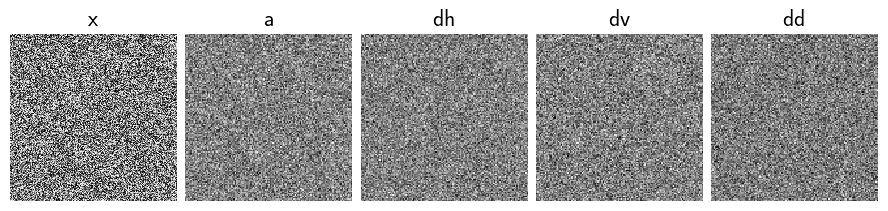

In [70]:
import deepinv as dinv
import torch
import torch.nn.functional as F

# Wavelet transform (Haar)

k1 = torch.tensor([1., 1.])
k2 = torch.tensor([1., -1.])

filter_ll = torch.outer(k1, k1).unsqueeze(0).unsqueeze(0)
filter_lh = torch.outer(k1, k2).unsqueeze(0).unsqueeze(0)
filter_hl = torch.outer(k2, k1).unsqueeze(0).unsqueeze(0)
filter_hh = torch.outer(k2, k2).unsqueeze(0).unsqueeze(0)

x = torch.rand(1, 1, 256, 256)  # Example input
a = F.conv2d(x, filter_ll, padding=0, stride=2)
dh = F.conv2d(x, filter_lh, padding=0, stride=2)
dv = F.conv2d(x, filter_hl, padding=0, stride=2)
dd = F.conv2d(x, filter_hh, padding=0, stride=2)

print(x.shape)

print(a.shape)

dinv.utils.plot([x, a, dh, dv, dd], titles=['x', 'a', 'dh', 'dv', 'dd'])

tensor(7701.0659)


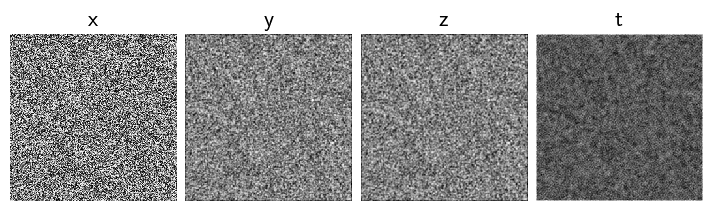

In [74]:
blur_kernel = torch.tensor([1., 2., 1.])
blur_filter = torch.outer(blur_kernel, blur_kernel).unsqueeze(0).unsqueeze(0)

def A(x):
    return F.conv2d(x, blur_filter, padding="same")

def At(y):
    return F.conv_transpose2d(y, blur_filter, padding=1)

def AtA(x):
    blur_flip = torch.flip(blur_filter, [2, 3])
    filter_prod = F.conv2d(blur_filter, blur_flip, padding="same")
    return F.conv2d(x, filter_prod, padding="same")

y = A(x)
z = AtA(x)

t = AtA(x) - A(At(x)) # Should be zero
print(torch.norm(t, p='fro'))

dinv.utils.plot([x, y, z, t], titles=['x', 'y', 'z', 't'])

In [55]:
import torch
import torch.nn.functional as F
import deepinv.utils

blur_kernel = torch.tensor([1., 2., 1.])
blur_filter = torch.outer(blur_kernel, blur_kernel).unsqueeze(0).unsqueeze(0)  # 1x1x3x3

def A(x):
    return F.conv2d(x, blur_filter, padding=1)

def At(y):
    return F.conv_transpose2d(y, blur_filter, padding=1)

def AtA(x):
    return At(A(x))

x = torch.randn(1,1,16,16)

# Calcul du kernel effectif AtA
blur_flip = torch.flip(blur_filter.squeeze(), [0,1])  # flip 2D
AtA_filter = F.conv2d(
    blur_flip.unsqueeze(0).unsqueeze(0),
    blur_filter,
    padding=0
).squeeze()  # 5x5

print(AtA_filter)

# Reconstruction 4D pour conv2d
AtA_filter_4D = AtA_filter.unsqueeze(0).unsqueeze(0)  # 1x1x5x5
print(AtA_filter_4D.shape)

# Tests
y = A(x)
z = AtA(x)
z2 = F.conv2d(x, AtA_filter_4D, padding=2)
t = z - z2  # devrait être ~0

dinv.utils.plot([x, y, z, z2, t],
                titles=['x', 'A(x)', 'AtA(x)', 'conv2d(x, AtA_filter)', 'diff'])


tensor(36.)
torch.Size([1, 1])


RuntimeError: weight should have at least three dimensions